# Metaheurísticas aplicadas ao problema do Posicionamento Ótimo de Sensores

### O Problema do Posicionamento Ótimo de Sensores (OSP: *Optimal Sensor Placement*)

O objetivo central é determinar os melhores locais para instalar sensores para monitorar um sistema. Dependendo do domínio, o 'ótimo' pode significar coisas diferentes:

#### 1. Monitoramento de Vibrações (SHM)
Como visto no critério **MAC**, o objetivo é posicionar sensores em pontos onde as formas modais da estrutura sejam linearmente independentes. Isso permite identificar falhas estruturais, como trincas em pontes ou fadiga em pás eólicas, através da mudança no comportamento dinâmico.

#### 2. Redes de Sensores Sem Fio e IoT
Em contextos de Internet das Coisas (IoT), o problema foca em:
*   **Cobertura de Área:** Garantir que todos os pontos de interesse estejam dentro do raio de sensoriamento (como na função `calcular_cobertura_faltante`).
*   **Conectividade:** Posicionar sensores de forma que eles consigam transmitir dados uns aos outros até um *gateway*.
*   **Consumo de Energia:** Minimizar a redundância para aumentar a vida útil das baterias da rede.

#### 3. Cidades Inteligentes e Meio Ambiente
*   **Qualidade do Ar:** Localizar sensores para detectar plumas de poluição com rapidez.
*   **Redes de Água:** Posicionar sensores de pressão para identificar vazamentos através de transientes hidráulicos.

Metaheurísticas como **GA, PSO e DE** (implementadas abaixo) são ideais para resolver esses problemas, pois o espaço de busca é frequentemente discreto, não-linear e repleto de ótimos locais.

In [206]:
import numpy as np
import matplotlib.pyplot as plt
# import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d


## Funções de Plotagem e Geração de População Aleatória

In [207]:
def generate_random_population(bounds, popsize=100):
  dimension = len(bounds)
  return np.array([[np.random.uniform(xi_min, xi_max) for xi_min,xi_max in bounds] for _ in range(popsize)])


### Definição de pontos alvo e Geração de População de Posições de Sensores

In [208]:
vertices_Fundao = [
              [-43.2266508,-22.8565992],
              [-43.2269941,-22.856352],
              [-43.2272838,-22.8562581],
              [-43.227509,-22.8561765],
              [-43.2278416,-22.8562234],
              [-43.2278362,-22.8566115],
              [-43.2274661,-22.8570786],
              [-43.2271872,-22.8576273],
              [-43.2269619,-22.8580871],
              [-43.2266722,-22.8584034],
              [-43.2261572,-22.8587198],
              [-43.2249771,-22.8590757],
              [-43.2246659,-22.858789],
              [-43.224446,-22.8585072],
              [-43.2251889,-22.8577484],
              [-43.2261304,-22.8569402],
              [-43.2266508,-22.8565992] ]

vertices_Fundao

[[-43.2266508, -22.8565992],
 [-43.2269941, -22.856352],
 [-43.2272838, -22.8562581],
 [-43.227509, -22.8561765],
 [-43.2278416, -22.8562234],
 [-43.2278362, -22.8566115],
 [-43.2274661, -22.8570786],
 [-43.2271872, -22.8576273],
 [-43.2269619, -22.8580871],
 [-43.2266722, -22.8584034],
 [-43.2261572, -22.8587198],
 [-43.2249771, -22.8590757],
 [-43.2246659, -22.858789],
 [-43.224446, -22.8585072],
 [-43.2251889, -22.8577484],
 [-43.2261304, -22.8569402],
 [-43.2266508, -22.8565992]]

In [209]:
from pyproj import Transformer

# 1. Configura a conversão: Entrada (WGS84) -> Saída (UTM Zona 23S - ex: região do Sudeste do BR)
# Substitua o '32723' pelo código EPSG correspondente à zona UTM do seu ponto
transformador = Transformer.from_crs("epsg:4326", "epsg:32723", always_xy=True)

# 2. Insira a Longitude e a Latitude desejada
longitude, latitude = vertices_Fundao[0]

# 3. Executa a conversão para metros
x_metros, y_metros = transformador.transform(longitude, latitude)
print(f"X: {x_metros:.2f} m | Y: {y_metros:.2f} m")


def revert_transformation(x, y):
  """
  Converte coordenadas UTM (metros) de volta para Longitude e Latitude (graus).
  """
  transformador = Transformer.from_crs("epsg:4326", "epsg:32723", always_xy=True)
  lon, lat = transformador.transform(x, y, direction='inverse')
  return lon, lat


V_Fundao = np.array(vertices_Fundao)
V_Fundao[:,0], V_Fundao[:,1] = transformador.transform(V_Fundao[:,0], V_Fundao[:,1])
print(V_Fundao)

# Demonstração da função de reversão
lon_orig, lat_orig = revert_transformation(x_metros, y_metros)
print(f"Revertido: Longitude: {lon_orig:.6f} | Latitude: {lat_orig:.6f}")

X: 681947.37 m | Y: 7471260.59 m
[[ 681947.36655477 7471260.58772277]
 [ 681912.46486202 7471288.38505484]
 [ 681882.859636   7471299.14050152]
 [ 681859.8572682  7471308.45428555]
 [ 681825.66201396 7471303.67105332]
 [ 681825.69970291 7471260.68816072]
 [ 681863.05907798 7471208.50735447]
 [ 681890.95030453 7471147.40298782]
 [ 681913.45907879 7471096.20903587]
 [ 681942.76769099 7471060.82603027]
 [ 681995.19686512 7471025.15374867]
 [ 682115.8271918  7470984.28570445]
 [ 682148.14549134 7471015.64896268]
 [ 682171.08794019 7471046.58238669]
 [ 682095.86096085 7471131.52602747]
 [ 682000.3178532  7471222.1847314 ]
 [ 681947.36655477 7471260.58772277]]
Revertido: Longitude: -43.226651 | Latitude: -22.856599


[[3.  3. ]
 [4.  2. ]
 [3.  5.5]]


(array([False, False, False]), array([ True,  True,  True]))

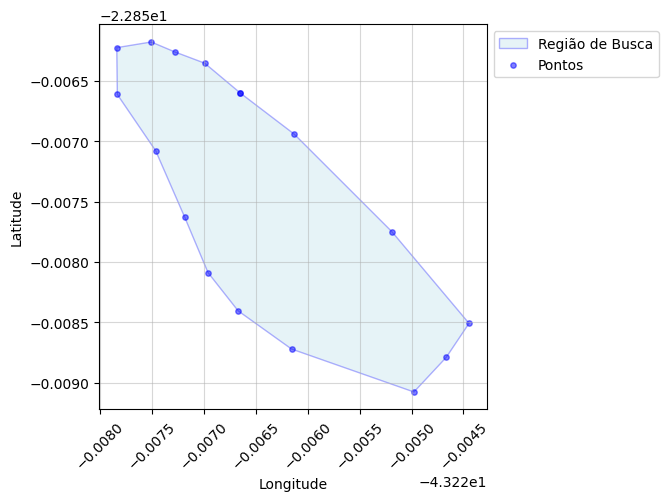

In [210]:
from matplotlib.patches import Polygon as MatplotlibPolygon
import shapely
from shapely.geometry import Polygon as ShapelyPolygon, Point

def create_area_grid(vertices, num_points_per_dim=100):
    """
    Cria uma grade de pontos alvo dentro de uma região definida pelos seus vértices.
    Args:
        vertices: Pontos que definem o polígono/região.
        num_points_per_dim: Número de pontos por dimensão, para definir o grid.
    Returns:
        pontos_dentro: array de pontos alvo no grid, delimitados pela região.
        grid_bounds: limites das dimensões do grid.
    """
    # ==========================================
    # DEFINIÇÃO DA GEOMETRIA (POLÍGONO)
    # ==========================================
    polygon = ShapelyPolygon(vertices)

    grid_min_x, grid_max_x = np.min(vertices, axis=0)[0], np.max(vertices, axis=0)[0]
    grid_min_y, grid_max_y = np.min(vertices, axis=0)[1], np.max(vertices, axis=0)[1]

    grid_bounds = [(grid_min_x, grid_max_x), (grid_min_y, grid_max_y)]

    # ==========================================
    # CRIAÇÃO DA GRID DE PONTOS
    # ==========================================
    x_range = np.linspace(grid_min_x, grid_max_x, num_points_per_dim)
    y_range = np.linspace(grid_min_y, grid_max_y, num_points_per_dim)
    X, Y = np.meshgrid(x_range, y_range)

    x_points = X.flatten()
    y_points = Y.flatten()

    target_points = []

    for x, y in zip(x_points, y_points):
        if polygon.contains(Point(x, y)):
            target_points.append([x, y])

    target_points = np.array(target_points)

    return target_points, grid_bounds


def solution_is_valid(vertices, solution):
  """
  Verifica se um ponto está dentro de uma região definida pelos vértices de um polígono.
  Args:
      vertices: Pontos que definem o polígono (região mapeada).
      solution: Pontos/posições de cada sensor.
  Returns:
      True se todos os pontos estiverem dentro da região, False caso contrário.
  """
  polygon = ShapelyPolygon(vertices)

  # 1. Cria os pontos vetorizados em C de uma só vez (sem criar objetos Python um por um)
  solution_points = shapely.points(solution)

  # 2. Executa a verificação vetorizada direto na biblioteca C
  inside_polygon = shapely.contains(polygon, solution_points)

  return np.all(inside_polygon), inside_polygon


# vertices = np.array([(2, 2), (4, 8.5), (8, 8), (9, 4), (6,4), (5, 2)])
vertices = np.array(vertices_Fundao)
# vertices = V_Fundao
points = np.array([(3,3), (4,2), (3,5.5)])
fig = plt.figure(figsize=(5, 5))

ax1 = fig.add_subplot(1, 1, 1)
# Desenha a área do polígono
patch_2d = MatplotlibPolygon(vertices, closed=True, facecolor='lightblue',
                              edgecolor='blue', alpha=0.3, label='Região de Busca')
ax1.add_patch(patch_2d)

ax1.scatter(vertices[:,0], vertices[:,1],
              color='blue', s=15, alpha=0.5, label='Pontos')

ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, linestyle='-', alpha=0.5)

# Ajustando a legenda para fora do gráfico
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)

_, points_inside = solution_is_valid(vertices, points)
points_outside = points[~points_inside]
print(points_outside)

points_inside, ~points_inside

In [211]:
def get_estimate_of_N_sensors(vertices, raio_sensoriamento):
  """
  Estima o número de sensores que podem ser instalados dentro de uma região.
  Args:
      vertices: Pontos que definem o polígono (região
      raio_sensoriamento: raio de sensoriamento
  Returns:
      Estimativa da quantidade de sensores necessários para cobrir a área.
  """
  polygon = ShapelyPolygon(vertices)
  N_sensors_estimate = int(np.ceil( polygon.area / (np.pi * raio_sensoriamento**2) ))

  return N_sensors_estimate


def generate_random_population_of_sensors(num_sensors, target_points, pop_size):
  """
  Gera posições aleatórias para um número de sensores dentro dos limites da grade.
  Args:
      num_sensors: número de sensores
      target_points: pontos alvo da região
      pop_size: tamanho da população de posições de sensores
  Returns:
      sensor_positions: array com população de posições dos sensores
  """
  n_points_per_sensor = int(len(target_points) / num_sensors)

  if(n_points_per_sensor < 1):
    print("Quantidade de sensores maior que a de pontos!")
    return None

  dimension = target_points.shape[1]

  # Amostra de tamanho 4*num_sensors para evitar escolhas iguais
  target_points_spaced_sample = target_points[::(n_points_per_sensor//4)]

  sensor_positions_population = []

  i=0
  while(i < pop_size):
    # Escolhe num_sensors posições sem repetição
    indices = np.random.choice(len(target_points_spaced_sample), size=num_sensors, replace=False)
    sensor_positions = target_points_spaced_sample[indices].tolist()

    # Se indivíduo não existe na população, adiciona, senão, avança o loop sem aumentar contador
    if(sensor_positions not in sensor_positions_population):
      sensor_positions_population.append(sensor_positions)
      i+=1

  return np.array(sensor_positions_population)


### Plotagem de Soluções

In [212]:
def plot_solution(vertices, target_points, sensor_positions, sensors_per_point, raio_sensoriamento):
  fig = plt.figure(figsize=(5, 5))

  ax1 = fig.add_subplot(1, 1, 1)
  # Desenha a área do polígono
  patch_2d = MatplotlibPolygon(vertices, closed=True, facecolor='lightblue',
                                edgecolor='blue', alpha=0.3, label='Região de Busca')
  ax1.add_patch(patch_2d)

  priority_target_points = target_points[(sensors_per_point>1)]
  normal_target_points = target_points[(sensors_per_point==1)]

  # Desenha os pontos internos e pontos dos sensores
  ax1.scatter(normal_target_points[:,0], normal_target_points[:,1],
              color='blue', s=15, alpha=0.5, label='Alvos Normais (spp=1)')
  ax1.scatter(priority_target_points[:,0], priority_target_points[:,1],
              color='red', s=25, label='Alvos Prioritários (spp>1)')
  ax1.scatter(sensor_positions[:,0], sensor_positions[:,1], marker="x",
              color='black', s=100, linewidths=1.5, label='Sensores (Solução)')

  # Desenha o raio de alcance para cada sensor
  for i, s in enumerate(sensor_positions):
    lbl = 'Raio de Cobertura' if i == 0 else ""
    circle = plt.Circle((s[0], s[1]), raio_sensoriamento, color='red', fill=True, alpha=0.2, label=lbl)
    ax1.add_patch(circle)

  ax1.set_title(f'Visualização da Solução de Posicionamento \npara {sensor_positions.shape[0]} sensores de raio {raio_sensoriamento}')
  ax1.set_xlabel('Coordenada X')
  ax1.set_ylabel('Coordenada Y')

  ax1.grid(True, linestyle='-', alpha=0.5)

  # Ajustando a legenda para fora do gráfico
  ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
  plt.xticks(rotation=45)


In [213]:
v = [(2, 2), (4, 8.5), (8, 8), (9, 4), (6,4), (5, 2)]
target_points, grid_bounds = create_area_grid(v, num_points_per_dim=20)
# target_points[:10]

S_pop = generate_random_population_of_sensors(num_sensors=10, target_points=target_points, pop_size=10)
# S_pop[:2]

sensors_per_point = np.ones(len(target_points))
# Os indices podem ser definidos individualmente também
indices_priority_sensors = np.random.choice(len(target_points), size=4, replace=False)
sensors_per_point[indices_priority_sensors] = 2


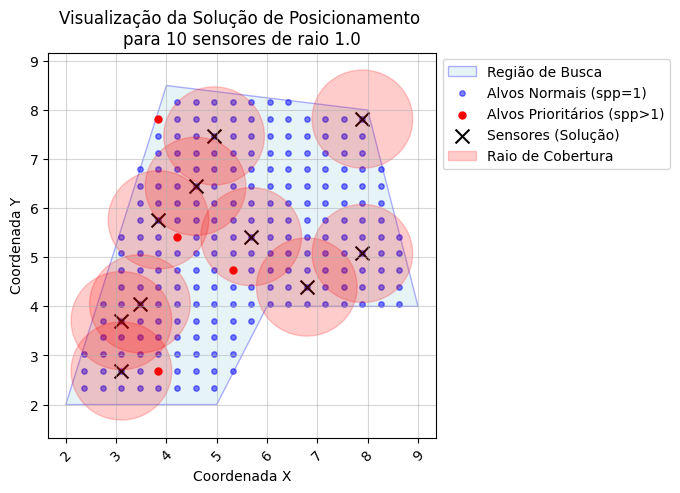

In [214]:
k = 0
plot_solution(vertices=v, target_points=target_points,
              sensor_positions=S_pop[k], sensors_per_point=sensors_per_point, raio_sensoriamento=1.)

## Algoritmos das Metaheurísticas



### Algoritmo Genético

In [248]:
def get_fitness(P, f):
  # Como a roleta privilegia valores altos, definimos fitness nova
  # inversamente proporcional aos valores da original por meio
  # de e^(-c*x), esta não implica em divisão por zero
  c = .5 # c controla a velocidade de crescimento

  # Calculate fitness for each individual in the population P
  # This part iterates over the population because 'f' (OSP_fitness) operates on single solutions.
  original_fitness_values = np.array([f(X) for X in P])

  # Apply the exponential transformation in a vectorized way
  return np.exp(-c * original_fitness_values)

def blx_recombine(parent1, parent2):
  alpha = .5
  beta = np.random.uniform(-alpha, 1+alpha)
  return parent1 + beta*(parent2 - parent1)

def creep_mutate(child):
  creep_sd = .8
  return child + np.random.normal(0, creep_sd, child.shape)


def GA(f, initial_population, check_solution,
       recombination_rate=.7, mutation_rate=.02, generations=100):

  # população inicial
  P = initial_population.copy()
  size_P = P.shape[0]
  P_fitness = get_fitness(P, f)

  n_recomb = int(size_P * recombination_rate)
  geracoes_estacionarias = 0
  best, best_fx = [], []

  for _ in range(generations):
    P_fitness_ac = np.cumsum(P_fitness)
    P_descendent = []

    for i in range(size_P):
      if(i < n_recomb):
        # seleciona por Roleta e recombina por BLX
        n1, n2 = np.random.uniform(0, P_fitness_ac[-1], 2)
        i1, i2 = np.argmin(P_fitness_ac < n1), np.argmin(P_fitness_ac < n2)
        parent1, parent2 = P[i1], P[i2]
        child = blx_recombine(parent1, parent2)

        # Muta por Creep
        if(np.random.random() < mutation_rate):
          child = creep_mutate(child)

        if( not check_solution(child)[0] ): # se solução é inválida (está fora dos limites)
          child = parent1 if P_fitness[i1]>=P_fitness[i2] else parent2 # seleciona o melhor dos pais

      else:
        # seleciona por Roleta
        n = np.random.uniform(0, P_fitness_ac[-1])
        parent_i = np.argmin(P_fitness_ac < n)
        child = P[parent_i]

      P_descendent.append(child)

    P_descendent = np.array(P_descendent)
    P_fitness_descendent = get_fitness(P_descendent, f)

    # if(abs(P_fitness.max()-P_fitness_descendent.max()) < .001):
    #   geracoes_estacionarias += 1

    P = P_descendent
    P_fitness = P_fitness_descendent
    best.append( P[np.argmax(P_fitness)] )
    best_fx.append( f(best[-1]) )

  global_best_idx = np.argmin(best_fx)
  global_best, global_best_fx = best[global_best_idx], best_fx[global_best_idx]

  return global_best, global_best_fx


### Evolução Diferencial

In [216]:
# Implementação autoral do DE

# "Indicações de Storn e Price: F in [0.5, 1.0] e CR in [0.8, 1.0]"
def de_x_y_bin(f, initial_population, check_solution,
               mut=0.7, crossp=0.85, mut_vector="rand", N_diff=1, its=1000):

  # mut_vector = {"rand", "best", "current-to-best"}
  # N_diff = {1,2} (Número de vetores de diferença)

  if(its<1):
    print("Defina pelo menos 1 iteração")
    return None

  population = initial_population.copy()
  NP = population.shape[0] # tamanho da população de indivíduos
  D = population.shape[1] # dimension (quantidade de sensores por indivíduo)

  fitness = np.array([f(ind) for ind in population])
  best_list, best_fitness_list = [], []
  next_population, next_fitness = population.copy(), fitness.copy()

  for i in range(its):
    for j in range(NP):
      x = population[j] # target

      ## Mutação
      if(mut_vector=="rand"):
        if(N_diff==1):
          idxs = [idx for idx in range(NP) if idx != j]
          x_r1, x_r2, x_r3 = population[np.random.choice(idxs, 3, replace = False)]
          v = x_r1 + mut*(x_r2 - x_r3) # mutante
        elif(N_diff==2):
          idxs = [idx for idx in range(NP) if idx != j]
          x_r1, x_r2, x_r3, x_r4, x_r5 = population[np.random.choice(idxs, 5, replace = False)]
          v = x_r1 + mut*(x_r2 - x_r3 + x_r4 - x_r5) # mutante

      elif(mut_vector=="best"):
        x_best = population[np.argmin(fitness)]
        if(N_diff==1):
          idxs = [idx for idx in range(NP) if idx != j]
          x_r1, x_r2 = population[np.random.choice(idxs, 2, replace = False)]
          v = x_best + mut*(x_r1 - x_r2) # mutante
        elif(N_diff==2):
          idxs = [idx for idx in range(NP) if idx != j]
          x_r1, x_r2, x_r3, x_r4 = population[np.random.choice(idxs, 4, replace = False)]
          v = x_best + mut*(x_r1 - x_r2 + x_r3 - x_r4) # mutante

      elif(mut_vector=="current-to-best"):
        x_best = population[np.argmin(fitness)]
        if(N_diff==1):
          idxs = [idx for idx in range(NP) if idx != j]
          x_r1, x_r2 = population[np.random.choice(idxs, 2, replace = False)]
          v = x + mut*(x_best - x) + mut*(x_r1 - x_r2) # mutante

      else:
        print("Estratégia de mutação não identificada")
        return None

      ## Crossover
      # rand_k garante que o vetor de trial recebe pelo menos uma entrada/parâmentro do de mutação
      rand_k = np.random.randint(D)
      u = np.array([(v[k] if(np.random.rand()<=crossp or k==rand_k) else x[k])
                     for k in range(D)]) # trial
      ## Selection
      if( check_solution(u)[0] ): # se solução é válida (não está fora dos limites)
        trial_fitness = f(u)
        if(trial_fitness < fitness[j]):
          next_population[j], next_fitness[j] = u, trial_fitness

    # Gerada nova população/geração
    population, fitness = next_population.copy(), next_fitness.copy()
    best_idx = np.argmin(fitness)
    best = population[best_idx]

    best_list.append(best)
    best_fitness_list.append(fitness[best_idx])

  best_list, best_fitness_list = np.array(best_list), np.array(best_fitness_list)
  global_best_idx = np.argmin(best_fitness_list)

  return best_list[global_best_idx], best_fitness_list[global_best_idx]


### PSO (Particle Swarm Optimization)

In [217]:
# hiperparâmetros
pso_parameters = {'swarm_size':30, 'w':0.3,
                  'c1': 0.5, 'c2': 0.3, 'w_linear_reduction': False}
pso_parameters_LR = {'swarm_size':100, 'w_linear_reduction': True}

def pso(f, initial_population, check_solution, parameters, it=100):
  swarm_size = parameters['swarm_size']

  if(parameters['w_linear_reduction']):
    w_max, w_min, c1, c2 = .9, .4, 2, 2
  else:
    w, c1, c2 = parameters['w'], parameters['c1'], parameters['c2']

  # n = len(bounds)
  x = initial_population.copy()
  v = np.random.rand(*(initial_population.shape))*.1 # velocidades iniciais próximas de zero
  # v = np.zeros(swarm_size)
  p = x.copy() # melhores posições de cada partícula
  f_p = np.array([f(pi) for pi in p])
  g_index = np.argmin(f_p) # índice da melhor posição global

  for k in range(it):
    for i in range(swarm_size):
      r1, r2 = np.random.rand(2)
      if(parameters['w_linear_reduction']):
        w = w_max - k*(w_max-w_min)/it

      v_i = w*v[i] + c1*r1*(p[i]-x[i]) + c2*r2*(p[g_index]-x[i])
      x_i = x[i]
      x_i += v_i
      valid, positions_inside = check_solution(x_i)
      positions_outside = ~positions_inside # outside problem boundaries
      if(not valid):
        v_i[positions_outside] = -v_i[positions_outside]/2
        x_i[positions_outside] += v_i[positions_outside]

      v[i] = v_i
      x[i] = x_i
      f_xi = f(x[i])

      if( f_xi < f_p[i] ):
        p[i], f_p[i] = x[i], f_xi
        if( f_xi < f_p[g_index] ):
          g_index = i

  return p[g_index], f_p[g_index]


## Função Objetivo do OSP e Função de Fitness de cada solução

In [218]:
## Função Objetivo do OSP (queremos minimizar)
def calcula_cobertura_faltante(posicao_sensores, pontos_alvo, raio_sensoriamento):
    """
    Calcula a porcentagem de pontos descobertos de uma solução.

    posicao_sensores: array de n pontos com as coordenadas dos sensores [[x1, y1, z1], ...]
    pontos_alvo: array de m pontos alvo com as coordenadas destes
    raio_sensoriamento: float com a capacidade de alcance do sensor
    """
    # if(posicao_sensores.shape[1] != pontos_alvo.shape[1]):
    #   print("Dimensões incompatíveis!")
    #   return None

    S, P = posicao_sensores, pontos_alvo
    n, m, dimensao = S.shape[0], P.shape[0], S.shape[1]

    D = S.reshape((n, 1, dimensao)) - P.reshape((1, m, dimensao))
    D = np.sqrt(np.sum(D**2, axis=2)) # matriz de distâncias (n x m)
    # D = np.astype(D, np.float32)
    # mudando tipo para economizar armazenamento, o tipo vai depender
    # dos valores extremos e precisão requeridos para o problema

    # Verifica quais pontos estão dentro do raio de alcance (distancia <= raio de sensoriamento)
    cobertos_por_sensor = (D <= raio_sensoriamento)

    # Um ponto é coberto se pelo menos um sensor o alcança (any ao longo do eixo dos sensores)
    pontos_cobertos = np.any(cobertos_por_sensor, axis=0)
    # Retorna a taxa de pontos descobertos (a minimizar)
    porcentagem_cobertura_faltante = (1 - np.sum(pontos_cobertos)/m)*100

    return porcentagem_cobertura_faltante


def OSP_fitness(posicao_sensores, pontos_alvo, raio_sensoriamento, sensores_por_ponto):
    """
    Calcula a fitness de cada solução.

    posicao_sensores: array de n pontos com as coordenadas dos sensores [[x1, y1, z1], ...]
    pontos_alvo: array de m pontos alvo com as coordenadas destes
    raio_sensoriamento: float com a capacidade de alcance do sensor
    sensores_por_ponto: array com a quantidade de sensores por ponto alvo
    """
    S, P = posicao_sensores, pontos_alvo
    n, m, dimensao = S.shape[0], P.shape[0], S.shape[1]

    D = S.reshape((n, 1, dimensao)) - P.reshape((1, m, dimensao))
    D = np.sqrt(np.sum(D**2, axis=2), dtype=np.float32) # matriz de distâncias (n x m)
    # D = np.astype(D, np.float32)
    # mudando tipo para economizar armazenamento, o tipo vai depender
    # dos valores extremos e precisão requeridos para o problema

    # Verifica quais pontos estão dentro do raio de alcance (distancia <= raio de sensoriamento)
    cobertos_por_sensor = (D <= raio_sensoriamento)

    spp_solucao = np.sum(cobertos_por_sensor, axis=0)
    fitness = 1*np.sum(spp_solucao > sensores_por_ponto) + 2*np.sum(spp_solucao < sensores_por_ponto)

    return fitness


## Instanciação do problema

### Definição da região mapeada, quantidade de sensores, e seu raio de sensoriamento ($r_s$) individual.

A quantidade de sensores (`n_sensors`) necessária para a região é estimada pela fórmula:

$$ \text{# sensores} = \bigg\lceil \frac{\text{área da região}}{\pi \times r_s^2} \bigg\rceil $$

In [309]:
## Definição da região mapeada

v = [(2, 2), (4, 8.5), (8, 8), (9, 4), (6,4), (5, 2)]
# v = V_Fundao
target_points, grid_bounds = create_area_grid(v, num_points_per_dim=20)

## Definição do do raio de sensoriamento e estimativa da qtd. de sensores
r_s = 1.0 # 50.0
n_sensors = get_estimate_of_N_sensors(vertices=v, raio_sensoriamento=r_s)
print(f"Número estimado de sensores: {n_sensors}")


Número estimado de sensores: 10


### Definição do tamanho da população de conjuntos de posições de sensores, e dos pontos-alvo prioritários a partir da lista de sensores por ponto

Melhor Fitness da população: 
130 (cobertura faltante = 23.77%)


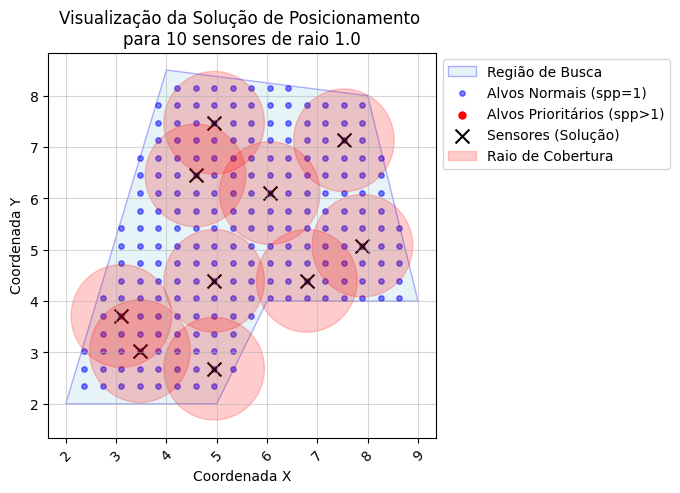

In [310]:
pop_size = 400

## Geração de população inicial de posições de sensores
S_pop = generate_random_population_of_sensors(num_sensors=n_sensors, target_points=target_points, pop_size=pop_size)
# S_pop[:2]

sensors_per_point = np.ones(len(target_points))
# Os indices podem ser definidos individualmente também
# indices_priority_sensors = np.random.choice(len(target_points), size=4, replace=False)
# sensors_per_point[indices_priority_sensors] = 2

f_obj_pop_results = [OSP_fitness(S_pop_i, target_points, r_s, sensors_per_point)
                     for S_pop_i in S_pop]

k = np.argmin(f_obj_pop_results)
cobertura_faltante = calcula_cobertura_faltante(S_pop[k], target_points, r_s)
print(f"Melhor Fitness da população: \n{np.min(f_obj_pop_results)} (cobertura faltante = {cobertura_faltante:.2f}%)")
# print(f"Pior Fitness da população: \n{np.max(f_obj_pop_results)}")


plot_solution(vertices=v, target_points=target_points,
              sensor_positions=S_pop[k], sensors_per_point=sensors_per_point, raio_sensoriamento=r_s)


## Solução por PSO

In [311]:
def fitness(sensors_pos):
  return OSP_fitness(sensors_pos, target_points, r_s, sensors_per_point)
def check_solution(sensors_pos):
  return solution_is_valid(vertices=v, solution=sensors_pos)

Melhor Fitness da população: 
42 (cobertura faltante = 7.62%)
cobertura_faltante_PSO/cobertura_faltante = 32.08%


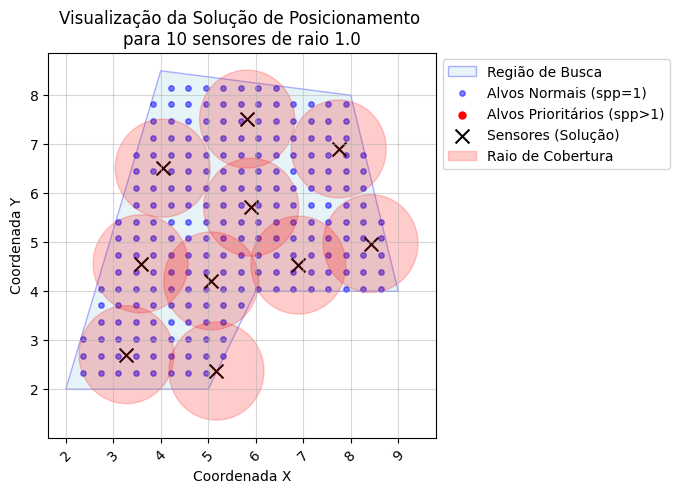

In [318]:
### PSO

pso_parameters = {'swarm_size':pop_size, 'w':0.3,
                  'c1': 0.5, 'c2': 0.3, 'w_linear_reduction': False}
pso_parameters_LR = {'swarm_size':pop_size, 'w_linear_reduction': True}

best_sensor_pos_PSO, fitness_best_sensor_pos_PSO = pso(fitness, S_pop, check_solution, pso_parameters_LR, it=500)

plot_solution(vertices=v, target_points=target_points,
              sensor_positions=best_sensor_pos_PSO,
              sensors_per_point=sensors_per_point, raio_sensoriamento=r_s)


cobertura_faltante_PSO = calcula_cobertura_faltante(best_sensor_pos_PSO, target_points, r_s)
print(f"Melhor Fitness da população: \n{np.min(fitness_best_sensor_pos_PSO)} (cobertura faltante = {cobertura_faltante_PSO:.2f}%)")
print(f"cobertura_faltante_PSO/cobertura_faltante = {cobertura_faltante_PSO/cobertura_faltante * 100:.2f}%")


## Solução por DE

Melhor Fitness da população: 
24 (cobertura faltante = 3.59%)
cobertura_faltante_DE/cobertura_faltante = 15.09%


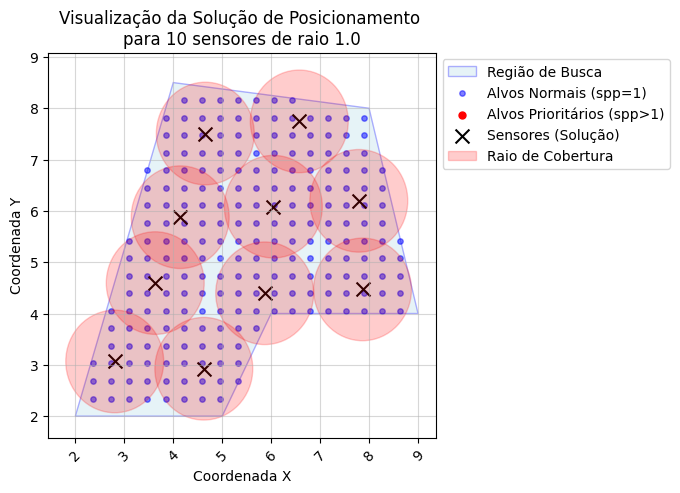

In [319]:
### DE
# mut_vector = {"rand", "best", "current-to-best"}
# N_diff = {1,2} (Número de vetores de diferença)

best_sensor_pos_DE, fitness_best_sensor_pos_DE = de_x_y_bin(fitness, S_pop, check_solution,
                                                            mut_vector="best", N_diff=1, its=500)

plot_solution(vertices=v, target_points=target_points,
              sensor_positions=best_sensor_pos_DE,
              sensors_per_point=sensors_per_point, raio_sensoriamento=r_s)


cobertura_faltante_DE = calcula_cobertura_faltante(best_sensor_pos_DE, target_points, r_s)
print(f"Melhor Fitness da população: \n{np.min(fitness_best_sensor_pos_DE)} (cobertura faltante = {cobertura_faltante_DE:.2f}%)")
print(f"cobertura_faltante_DE/cobertura_faltante = {cobertura_faltante_DE/cobertura_faltante * 100:.2f}%")


## Solução por GA

Melhor Fitness da população: 
111 (cobertura faltante = 15.70%)
cobertura_faltante_GA/cobertura_faltante = 66.04%


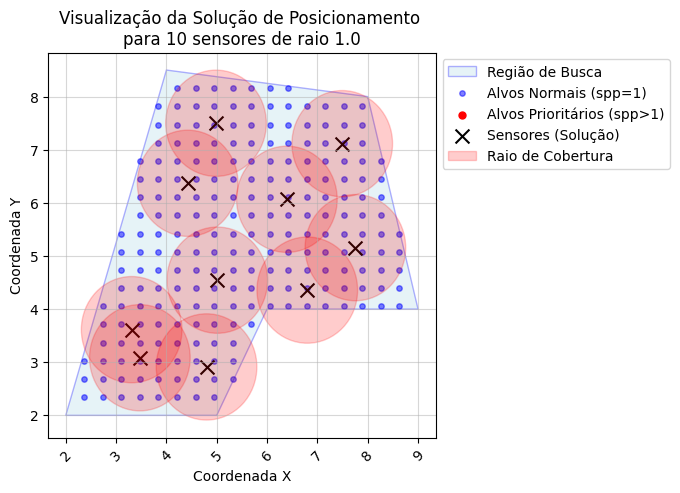

In [314]:
### GA

best_sensor_pos_GA, fitness_best_sensor_pos_GA = GA(fitness, S_pop, check_solution,
                                                    recombination_rate=.7, mutation_rate=.03, generations=500)

plot_solution(vertices=v, target_points=target_points,
              sensor_positions=best_sensor_pos_GA,
              sensors_per_point=sensors_per_point, raio_sensoriamento=r_s)

cobertura_faltante_GA = calcula_cobertura_faltante(best_sensor_pos_GA, target_points, r_s)
print(f"Melhor Fitness da população: \n{np.min(fitness_best_sensor_pos_GA)} (cobertura faltante = {cobertura_faltante_GA:.2f}%)")
print(f"cobertura_faltante_GA/cobertura_faltante = {cobertura_faltante_GA/cobertura_faltante * 100:.2f}%")


## Experimentação

In [333]:
## Definição da região mapeada

v = [(2, 2), (4, 8.5), (8, 8), (9, 4), (6,4), (5, 2)]
# v = V_Fundao
N_points_per_dim = 20
target_points, grid_bounds = create_area_grid(v, num_points_per_dim=N_points_per_dim)

## Definição do do raio de sensoriamento e estimativa da qtd. de sensores
r_s = 1.0 # 50.0
n_sensors = get_estimate_of_N_sensors(vertices=v, raio_sensoriamento=r_s)
print(f"Número estimado de sensores: {n_sensors}")


Número estimado de sensores: 10


In [334]:
rounds = 31
N_its = 500
pop_size = 400

OSP_experimentation_results = {
    "rounds": rounds,
    "N_its": N_its,
    "pop_size": pop_size,
    "PSO": {"solutions":[], "costs":[]},
    "DE": {"solutions":[], "costs":[]},
    "GA": {"solutions":[], "costs":[]}
}

# OSP_experimentation_results

### PSO

In [315]:
pso_parameters = {'swarm_size':pop_size, 'w':0.3,
                  'c1': 0.5, 'c2': 0.3, 'w_linear_reduction': False}
pso_parameters_LR = {'swarm_size':pop_size, 'w_linear_reduction': True}

for i in range(rounds):
  print(f"Rodada {i+1}")
  ## Geração de população inicial de posições de sensores
  S_pop = generate_random_population_of_sensors(num_sensors=n_sensors,
                                                target_points=target_points,
                                                pop_size=pop_size)
  sensors_per_point = np.ones(len(target_points))

  PSO_solution, _ = pso(fitness, S_pop, check_solution,
                           pso_parameters_LR, it=N_its)
  cost = calcula_cobertura_faltante(PSO_solution, target_points, r_s)

  OSP_experimentation_results['PSO']['solutions'].append([PSO_solution, cost])



KeyboardInterrupt: 

## Rascunho

In [ ]:
a = np.array([2,1,1,2])
b = np.array([3,0,1,2])
np.sum(a==b), np.sum(b>a), np.sum(b<a), b>a, b<a

## Tuning de Hiperparâmetros via Optuna

se der tempo ...

In [ ]:
!pip install optuna

In [ ]:
import optuna
import numpy as np

# Suponha que este seja o seu algoritmo PSO simplificado
def run_pso(inertia, cognitive, social):
    # Simulação da execução do PSO...
    # Aqui você implementaria o loop das partículas, avaliando uma função de custo.
    # O valor final retornado deve ser o melhor resultado (ex: o mínimo global encontrado).
    custo_final = np.random.uniform(0.1, 100) # Exemplo simulado
    return custo_final



# 1. Defina a função objetivo para o Optuna
def objective(trial):
    # Sugere valores para os hiperparâmetros do PSO
    inertia = trial.suggest_float("inertia", 0.1, 1.0)
    cognitive = trial.suggest_float("cognitive", 0.5, 2.0)
    social = trial.suggest_float("social", 0.5, 2.0)

    # Executa o PSO com os hiperparâmetros sugeridos
    resultado = run_pso(inertia, cognitive, social)

    # O objetivo do Optuna é minimizar este valor
    return resultado

# 2. Cria o estudo e inicia a otimização
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# 3. Exibe os resultados
print("Melhores hiperparâmetros encontrados: ", study.best_params)
print("Melhor valor de custo: ", study.best_value)
